<a href="https://colab.research.google.com/github/guadalupesbel-commits/EstadisticaVerano2026/blob/main/GymMembers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**GYM MEMBERS**

***INTRODUCCION***


**1.-¿Qué problema desea resolver el gimnasio?** Comprender mejor qué factores influyen en el gasto calórico durante una sesión de entrenamiento

**2.-¿Qué variables se analizarán?** Las base de datos fueron la edad, peso, estatura, frecuencia cardiaca, duración de la sesión, tipo de entrenamiento, frecuencia semanal y calorías quemadas

**3.-¿Por qué es útil estudiar la relación entre estas variables?**  Porque nos van a servir para ver cuales variables es la que mas aporta para quemar mas calorias

**4.-¿Cuál es el objetivo general del análisis?** Analisar las variables y tener un analisis y saber cual es la variable y que resultado daciertas variables

***METODOLOGIA***

**1.-¿Que base de datos se aplico?**

In [30]:
import pandas as pd

df = pd.read_csv("https://raw.githubusercontent.com/guadalupesbel-commits/EstadisticaVerano2026/refs/heads/main/Gym_Members/gym_members_exercise_tracking-selected-columns.csv")

df

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type
0,56,Male,88.3,1.71,180,157,60,1.69,1313.0,Yoga
1,46,Female,74.9,1.53,179,151,66,1.30,883.0,HIIT
2,32,Female,68.1,1.66,167,122,54,1.11,677.0,Cardio
3,25,Male,53.2,1.70,190,164,56,0.59,532.0,Strength
4,38,Male,46.1,1.79,188,158,68,0.64,556.0,Strength
...,...,...,...,...,...,...,...,...,...,...
968,24,Male,87.1,1.74,187,158,67,1.57,1364.0,Strength
969,25,Male,66.6,1.61,184,166,56,1.38,1260.0,Strength
970,59,Female,60.4,1.76,194,120,53,1.72,929.0,Cardio
971,32,Male,126.4,1.83,198,146,62,1.10,883.0,HIIT


In [31]:
Y = df["Calories_Burned"]      # Variable independiente
X = df["Session_Duration (hours)"]    # Variable dependiente

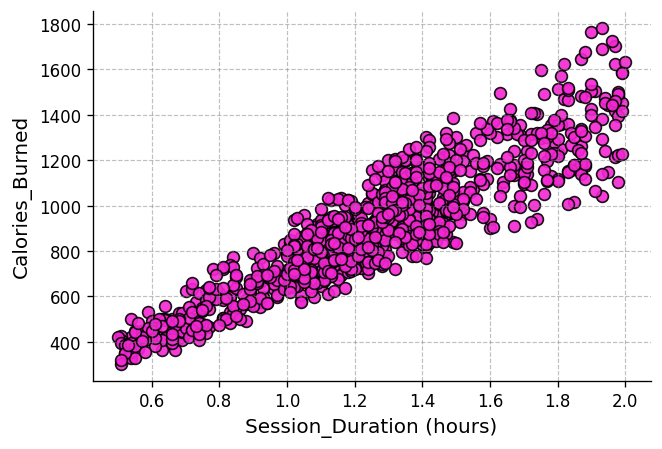

In [32]:
# Importamos la librería matplotlib.pyplot y le damos el pseudónimo plt
import matplotlib.pyplot as plt

# Configuración general del gráfico
plt.figure(
    figsize=(6, 4),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=120           # resolución del gráfico
)

# Gráfico de dispersión
plt.scatter(
    X, Y,
    marker="o",       # forma: googlear "matplotlib.markers"
    color='#F527D3',     # color de los puntos
    edgecolor='black',    # borde de los puntos
    alpha=0.9,            # transparencia: 0 es invisible y 1 es color sólido
    s=50,                 # tamaño de los puntos
)

# Etiquetas de los ejes
# eje x
plt.xlabel(
    'Session_Duration (hours)', # etiqueta del eje x
    fontsize=12  # tamaño de fuente
)

plt.ylabel(
    'Calories_Burned', # etiqueta del eje y
    fontsize=12 # tamaño de fuente
)

# Fuente de los ticks
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Márgenes
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Cuadrícula (opcional, pero didáctica)
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.5,
    color="gray"
)

Por lo que podemos ver en la grafica hay una relacion directa y clara, ya que a medida que aumenta el tiempo en la sesion, aumentaran las calorias quemadas.

**2.-¿Cuál fue el valor del coeficiente de correlación y cómo se interpreta?**

In [33]:
# Importar la función pearsonr desde scipy.stats
from scipy.stats import pearsonr

# Test de Pearson
# H0: rho = 0     (No hay correlación)
# H1: rho ≠ 0     (Sí hay correlación)
# alpha = 0.05

r, valor_p = pearsonr(X, Y)

print(f"Coeficiente de correlación: {r: 0.4f}")
print(f'valor_p: {valor_p: 0.4f}')

Coeficiente de correlación:  0.9081
valor_p:  0.0000


El coeficiente de $r=0.9081$ indica que existe una relación lineal muy fuerte y directa entre las variables $X$ e $Y$.

**3.-¿Cuál fue el coeficiente de determinación y qué porcentaje de la variabilidad explica el modelo?**

In [34]:
import statsmodels.api as sm
x_constante = sm.add_constant(X)
modelo = sm.OLS(Y, x_constante).fit()
y_calculada = modelo.predict(x_constante)

In [35]:
# Coeficiente de determinación
from sklearn.metrics import r2_score

r2 = r2_score(Y, y_calculada)

print(f"Coeficiente de determinación: {r2: 0.2%}")

Coeficiente de determinación:  82.47%


**4.-¿Cuál es la ecuación de regresión obtenida?**

**$R^2=0.8247$**

**5.-¿Qué significa la pendiente en el contexto del gimnasio?**

Una vez ajustado el modelo de regresión lienal, se obtiene un coeficiente calorico de $R^2=0.8247$. Entonces teniendo las horas de secion y el modelo ajustado, sólo podemos justificar la variabilidad en las calorias quemadas en un 82.47%, lo que es muy alto que fue considerado un ajuste fuertey positivo para los GYM RATS

**6.-¿Qué indican los residuales sobre la calidad del modelo?**

In [36]:
import pandas as pd
import statsmodels.api as sm

# Load the dataframe
df = pd.read_csv("https://raw.githubusercontent.com/guadalupesbel-commits/EstadisticaVerano2026/refs/heads/main/Gym_Members/gym_members_exercise_tracking-selected-columns.csv")

# Define X and Y variables
Y = df["Calories_Burned"]      # Variable dependiente (originally independent in comment, but dependent in code)
X = df["Session_Duration (hours)"]    # Variable independiente (originally dependent in comment, but independent in code)

# Add a constant to the independent variable
x_constante = sm.add_constant(X)

# Create and fit the OLS model
modelo = sm.OLS(Y, x_constante).fit()

# Print the model parameters
modelo.params

,0
const,-1.446459
Session_Duration (hours),721.786016
